### Imports and CUDA

In [15]:
# Torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import random
import json
import os
from helper_functions import *
import numpy as np
import pickle

import torch.backends.cudnn as cudnn

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
random.seed(SEED)
np.random.seed(SEED)

cudnn.deterministic = True
cudnn.benchmark = False

In [16]:
# Use GPU if available, else use CPU
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print(device)

mps


### DvXray Dataset
A large-scale dual-view X-ray baggage dataset for prohibited item detection.

- **Views:** Overlook (OL) & Side (SD) X-ray images
- **15 threat classes:** Gun, Knife, Hammer, Battery, etc.
- **Negative samples:** Benign baggage
- **Annotations:** JSON with bounding boxes

In [17]:
# DvXray Dataset
class DvXrayDataset(Dataset):
    """DvXray Dataset: dual-view X-ray baggage dataset for prohibited item detection.
    
    Args:
        transform: Optional transform to apply to each image.
        download: If True, downloads the dataset from Google Drive if not found.
    """
    
    def __init__(self, transform=None, download=False):
        # Download if requested
        if download and not check_dvxray_exists():
            download_and_extract_dvxray()
        neg_dir, pos_dir = get_directories()
        
        # Read dataset from directories
        self.samples = []
        self.labels = {}  # cache: ol_path -> list of label strings
        self.transform = transform

        # Add negative images into dataset
        for fname in os.listdir(neg_dir):
            if fname.endswith('_OL.png'):
                base = fname.replace('_OL.png', '')
                ol = os.path.join(neg_dir, base + '_OL.png')
                sd = os.path.join(neg_dir, base + '_SD.png')
                if os.path.exists(sd):
                    self.samples.append((ol, sd, 0))    # negatives = 0
                    self.labels[ol] = ["Benign"]
                else:
                    print(f"Missing SD for negative: {base}")

        # Add positive images into dataset
        for fname in os.listdir(pos_dir):
            if fname.endswith('_OL.png'):
                base = fname.replace('_OL.png', '')
                ol = os.path.join(pos_dir, base + '_OL.png')
                sd = os.path.join(pos_dir, base + '_SD.png')
                if os.path.exists(sd):
                    self.samples.append((ol, sd, 1))    # positives = 1
                    json_path = os.path.join(pos_dir, base + '.json')
                    obj_labels = []
                    if os.path.exists(json_path):
                        with open(json_path) as f:
                            data = json.load(f)
                        objects = data.get("objects")
                        if isinstance(objects, list) and len(objects) > 0:
                            for obj in objects:
                                obj_labels.append(obj["label"])
                        else:
                            obj_labels = ["Benign"]
                    else:
                        obj_labels = ["Benign"]
                    self.labels[ol] = obj_labels
                else:
                    print(f"Missing SD for positive: {base}")

        # Build label_map: Benign=0, threat classes sorted from 1
        all_labels = set()
        for label_list in self.labels.values():
            all_labels.update(label_list)

        self.label_map = {"Benign": 0}
        self.label_map.update(
            {label: i + 1 for i, label in enumerate(sorted(all_labels - {"Benign"}))}
        )
        self.num_classes = len(self.label_map)
    
    def __getitem__(self, idx):
        """Returns (image, vector, binary)"""
        ol_path, sd_path, binary_label = self.samples[idx]
        ol = Image.open(ol_path).convert('RGB')
        sd = Image.open(sd_path).convert('RGB')
        if self.transform:
            ol = self.transform(ol)
            sd = self.transform(sd)

        image = torch.cat([ol, sd], dim=0)
        multi_hot = torch.zeros(self.num_classes)
        for label_str in self.labels[ol_path]:
            if label_str in self.label_map:
                multi_hot[self.label_map[label_str]] = 1.0
    
        # (6 channel 128 x 128 image, vector of length num_classes, label)
        return image, multi_hot, binary_label  
    
    def __len__(self):
        """Return sample count"""
        return len(self.samples)
    
    def __repr__(self):
        """Return string representation of dataset"""
        pos_count = sum(1 for _, _, binary_label in self.samples if binary_label == 1)
        neg_count = len(self.samples) - pos_count
        return (f"DvXrayDataset(samples={len(self.samples)}, pos={pos_count}, neg={neg_count}, "
                f"classes={self.num_classes})\n"
                f"Labels: {', '.join(f'{v}:{k}' for k, v in self.label_map.items())}")

### Load the DvXray Dataset

In [18]:
# Default transform: resize, tensor conversion, and normalization
transform = transforms.Compose([
    # transforms.Resize((128, 128)),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    transforms.Normalize( mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load the data (downloads if not present)
dataset = DvXrayDataset(transform=transform, download=False)
print(dataset)

DvXrayDataset(samples=16000, pos=5000, neg=11000, classes=16)
Labels: 0:Benign, 1:Bat, 2:Battery, 3:Dart, 4:Fireworks, 5:Gun, 6:Hammer, 7:Knife, 8:Lighter, 9:Pliers, 10:Pressure_vessel, 11:Razor_blade, 12:Saw_blade, 13:Scissors, 14:Screwdriver, 15:Wrench


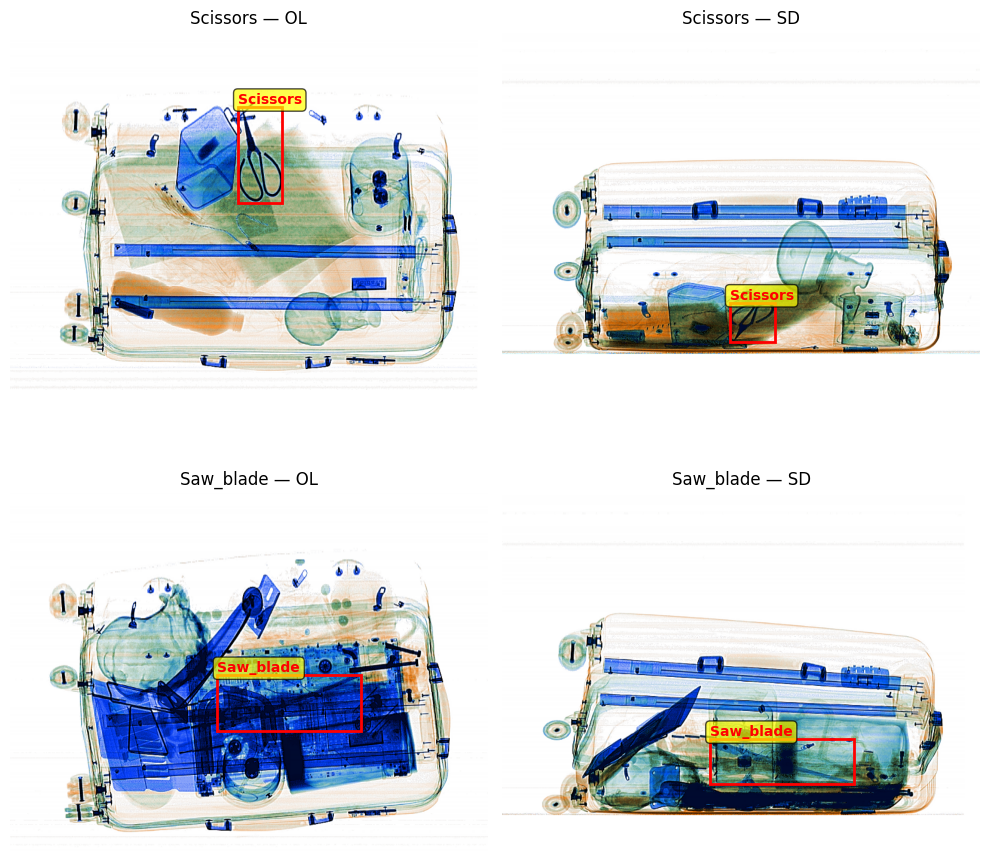

In [19]:
# Show first 2 classes
visualize_samples(dataset, n_classes=2)

### Split dataset (8-1-1) into Train-Validate-Test

In [20]:
from torch.utils.data import Subset

scale = 1.0
total_size = int(len(dataset) * scale)

g = torch.Generator().manual_seed(SEED)
indices = torch.randperm(len(dataset), generator=g)[:total_size].tolist()

subset = Subset(dataset, indices)

validate_size = int(0.10 * total_size)
test_size = int(0.10 * total_size)
train_size = total_size - validate_size - test_size

train_set, validate_set, test_set = random_split(
    subset, [train_size, validate_size, test_size], generator=g
)
batch_size = 32
train_loader = DataLoader(train_set, batch_size, shuffle=True, generator=g)
val_loader = DataLoader(validate_set, batch_size)
test_loader = DataLoader(test_set, batch_size)

print(f"Train set size: {len(train_set)}")
print(f"Validate set size: {len(validate_set)}")
print(f"Test set size: {len(test_set)}\n")
print(f"Number of classes: {dataset.num_classes}")
print(f"Sample shape: {train_set[0][0].shape}")

Train set size: 12800
Validate set size: 1600
Test set size: 1600

Number of classes: 16
Sample shape: torch.Size([6, 224, 224])


### 2 Layer CNN

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MyCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv1 = nn.Conv2d(6, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.4)

        # dynamically compute size
        self._to_linear = None
        self._get_conv_output()

        self.fc1 = nn.Linear(self._to_linear, 128)

        # TWO HEADS
        self.fc_multi = nn.Linear(128, num_classes)
        self.fc_binary = nn.Linear(128, 2)

    def _get_conv_output(self):
        with torch.no_grad():
            x = torch.zeros(1, 6, 224, 224)
            x = self.pool(F.relu(self.bn1(self.conv1(x))))
            x = self.pool(F.relu(self.bn2(self.conv2(x))))
            self._to_linear = x.view(1, -1).shape[1]

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))

        multi_out = self.fc_multi(x)
        binary_out = self.fc_binary(x)

        return multi_out, binary_out

### Added weights for multi-class

In [22]:

# Class imbalance for binary head
labels = [dataset.samples[i][2] for i in train_set.indices]
neg = labels.count(0)
pos = labels.count(1)
print(f"Class balance: {neg} negatives, {pos} positives")

weights = torch.tensor([neg/(neg+pos), pos/(neg+pos)])
weights = weights.to(device)

# multi class weight
# multi_counts = torch.zeros(dataset.num_classes)

# for i in train_set.indices:
#     _, multi_labels, _ = dataset[i]
#     multi_counts += multi_labels
multi_counts = torch.zeros(dataset.num_classes)

for i in train_set.indices:
    ol_path, _, _ = dataset.samples[i]
    label_list = dataset.labels[ol_path]
    
    for label in label_list:
        multi_counts[dataset.label_map[label]] += 1
        
pos_weight = (len(train_set) / (multi_counts + 1e-6))
pos_weight = torch.clamp(pos_weight, max=10)
pos_weight = pos_weight.to(device)
# Multi-label: BCEWithLogitsLoss (handles multi-hot targets)
criterion_multi = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# Binary: weighted CrossEntropyLoss
criterion_binary = nn.CrossEntropyLoss(weight=weights)

Class balance: 8785 negatives, 4015 positives


In [23]:
# train the model
# model = MyCNN().to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

model = MyCNN(num_classes=dataset.num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, multilabel_confusion_matrix

from pathlib import Path

save_path = Path("./results") / "cnn_experiment"
save_path.mkdir(parents=True, exist_ok=True)

model_file = save_path / "cnn_2layer.pth"
results_file = save_path / "results_cnn_2layer.pkl"

train_losses, val_losses, val_accs = [], [], []
all_preds = []
all_labels = []
best_val_acc = 0
best_epoch = 0
all_multi_preds = []
all_multi_labels = []
# Multi-class names for report
idx_to_label = {v: k for k, v in dataset.label_map.items()}
NUM_CLASSES = dataset.num_classes

for epoch in range(20):

    # ================= TRAIN =================
    model.train()
    total_loss = 0

    for images, multi_labels, binary_labels in train_loader:
        images = images.to(device)
        multi_labels = multi_labels.to(device)
        binary_labels = binary_labels.to(device)

        multi_out, binary_out = model(images)

        loss_multi = criterion_multi(multi_out, multi_labels)
        loss_binary = criterion_binary(binary_out, binary_labels)

        loss = 2.0* loss_multi + 1.0* loss_binary

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, multi_labels, binary_labels in val_loader:
            images = images.to(device)
            multi_labels = multi_labels.to(device)
            binary_labels = binary_labels.to(device)

            multi_out, binary_out = model(images)

            loss_multi = criterion_multi(multi_out, multi_labels)
            loss_binary = criterion_binary(binary_out, binary_labels)

            loss = 2.0* loss_multi + 1.0* loss_binary
            val_loss += loss.item()

            preds = torch.argmax(binary_out, dim=1)
            correct += (preds == binary_labels).sum().item()
            total += binary_labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/20 | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), model_file)
        print(f"  → Best model saved (val_acc: {val_acc:.4f})")

# Load best weights before testing
model.load_state_dict(torch.load(model_file, weights_only = True))
print(f"Loaded best model with val_acc: {best_val_acc:.4f}")

import pickle

results = {
    "train_losses": train_losses,
    "val_losses": val_losses,
    "val_accs": val_accs,
    "best_val_acc": best_val_acc,
    "best_epoch": best_epoch
}

with open(results_file, "wb") as f:
    pickle.dump(results, f)

# ================= FINAL TEST =================
model.eval()
correct = 0
total = 0
printed = False
with torch.no_grad():
    for images, multi_labels, binary_labels in test_loader:
        images = images.to(device)
        binary_labels = binary_labels.to(device)

        multi_out, binary_out = model(images)
        preds = torch.argmax(binary_out, dim=1)

        correct += (preds == binary_labels).sum().item()
        total += binary_labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(binary_labels.cpu().numpy())

        probs = torch.sigmoid(multi_out)
        # multi_preds = (probs > 0.5).int().cpu().numpy()
        multi_preds = (probs > 0.35).int().cpu().numpy()
        multi_labels = multi_labels.cpu().numpy()

        all_multi_preds.extend(multi_preds)
        all_multi_labels.extend(multi_labels)
    
        if not printed:
            # Show multi-label predictions (top predicted classes)
            probs = torch.sigmoid(multi_out)
            topk = torch.topk(probs[0], k=3)
            top_labels = [idx_to_label[i.item()] for i in topk.indices]
            top_probs = [f"{p:.3f}" for p in topk.values]
            print(f"Top predictions: {list(zip(top_labels, top_probs))}")

            pred_binary = torch.argmax(binary_out, dim=1)
            print("Pred threat:", ["Threat" if i.item()==1 else "No Threat" for i in pred_binary[:5]])
            printed = True
    
print(classification_report(all_labels, all_preds, target_names=['No Threat', 'Threat']))
print("Final Test Accuracy:", correct / total)

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix (Binary):")
print(cm)

print("\n=== MULTI-LABEL RESULTS ===")

print(classification_report(
    all_multi_labels,
    all_multi_preds,
    target_names=[idx_to_label[i] for i in range(NUM_CLASSES)]
))

Epoch 1/20 | Train Loss: 1.7292 | Val Loss: 1.0575 | Val Acc: 0.9313
  → Best model saved (val_acc: 0.9313)
Epoch 2/20 | Train Loss: 1.2449 | Val Loss: 0.9585 | Val Acc: 0.9494
  → Best model saved (val_acc: 0.9494)
Epoch 3/20 | Train Loss: 1.1932 | Val Loss: 0.9739 | Val Acc: 0.8906
Epoch 4/20 | Train Loss: 1.1892 | Val Loss: 0.9238 | Val Acc: 0.9625
  → Best model saved (val_acc: 0.9625)
Epoch 5/20 | Train Loss: 1.1672 | Val Loss: 0.9584 | Val Acc: 0.9625
Epoch 6/20 | Train Loss: 1.1438 | Val Loss: 0.9247 | Val Acc: 0.9663
  → Best model saved (val_acc: 0.9663)
Epoch 7/20 | Train Loss: 1.1251 | Val Loss: 0.9495 | Val Acc: 0.9694
  → Best model saved (val_acc: 0.9694)
Epoch 8/20 | Train Loss: 1.1192 | Val Loss: 0.9364 | Val Acc: 0.9606
Epoch 9/20 | Train Loss: 1.1182 | Val Loss: 0.9287 | Val Acc: 0.9637
Epoch 10/20 | Train Loss: 1.1052 | Val Loss: 0.9984 | Val Acc: 0.9456
Epoch 11/20 | Train Loss: 1.1002 | Val Loss: 0.9186 | Val Acc: 0.9750
  → Best model saved (val_acc: 0.9750)
Epoch

/opt/anaconda3/envs/torch310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 3 Layer CNN

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class My3CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv1 = nn.Conv2d(6, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.4)

        # dynamically compute size
        self._to_linear = None
        self._get_conv_output()

        self.fc1 = nn.Linear(self._to_linear, 256)

        # TWO HEADS
        self.fc_multi = nn.Linear(256, num_classes)
        self.fc_binary = nn.Linear(256, 2)

    def _get_conv_output(self):
        with torch.no_grad():
            x = torch.zeros(1, 6, 224, 224) 
            x = self.pool(F.relu(self.bn1(self.conv1(x))))
            x = self.pool(F.relu(self.bn2(self.conv2(x))))
            x = self.pool(F.relu(self.bn3(self.conv3(x))))
            self._to_linear = x.view(1, -1).shape[1]

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))

        multi_out = self.fc_multi(x)
        binary_out = self.fc_binary(x)

        return multi_out, binary_out

In [25]:
model = My3CNN(num_classes=dataset.num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

In [14]:

from sklearn.metrics import classification_report, confusion_matrix, multilabel_confusion_matrix

from pathlib import Path

save_path = Path("./results") / "cnn_experiment"
save_path.mkdir(parents=True, exist_ok=True)

model_file = save_path / "cnn_3layer.pth"
results_file = save_path / "results_cnn_3layer.pkl"

train_losses, val_losses, val_accs = [], [], []
all_preds = []
all_labels = []
best_val_acc = 0
best_epoch = 0
all_multi_preds = []
all_multi_labels = []
# Multi-class names for report
idx_to_label = {v: k for k, v in dataset.label_map.items()}
NUM_CLASSES = dataset.num_classes

for epoch in range(20):

    # ================= TRAIN =================
    model.train()
    total_loss = 0

    for images, multi_labels, binary_labels in train_loader:
        images = images.to(device)
        multi_labels = multi_labels.to(device)
        binary_labels = binary_labels.to(device)

        multi_out, binary_out = model(images)

        loss_multi = criterion_multi(multi_out, multi_labels)
        loss_binary = criterion_binary(binary_out, binary_labels)

        loss = 2.0* loss_multi + 1.0* loss_binary

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, multi_labels, binary_labels in val_loader:
            images = images.to(device)
            multi_labels = multi_labels.to(device)
            binary_labels = binary_labels.to(device)

            multi_out, binary_out = model(images)

            loss_multi = criterion_multi(multi_out, multi_labels)
            loss_binary = criterion_binary(binary_out, binary_labels)

            loss = 2.0* loss_multi + 1.0* loss_binary
            val_loss += loss.item()

            preds = torch.argmax(binary_out, dim=1)
            correct += (preds == binary_labels).sum().item()
            total += binary_labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/20 | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), model_file)
        print(f"  → Best model saved (val_acc: {val_acc:.4f})")

# Load best weights before testing
model.load_state_dict(torch.load(model_file, weights_only = True))
print(f"Loaded best model with val_acc: {best_val_acc:.4f}")

import pickle

results = {
    "train_losses": train_losses,
    "val_losses": val_losses,
    "val_accs": val_accs,
    "best_val_acc": best_val_acc,
    "best_epoch": best_epoch
}

with open(results_file, "wb") as f:
    pickle.dump(results, f)

# ================= FINAL TEST =================
model.eval()
correct = 0
total = 0
printed = False
all_preds = []
all_labels = []
all_multi_preds = []
all_multi_labels = []
with torch.no_grad():
    for images, multi_labels, binary_labels in test_loader:
        images = images.to(device)
        binary_labels = binary_labels.to(device)
        multi_labels = multi_labels.to(device)

        multi_out, binary_out = model(images)
        preds = torch.argmax(binary_out, dim=1)

        correct += (preds == binary_labels).sum().item()
        total += binary_labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(binary_labels.cpu().numpy())

        probs = torch.sigmoid(multi_out)
        # multi_preds = (probs > 0.5).int().cpu().numpy()
        multi_preds = (probs > 0.35).int().cpu().numpy()
        multi_labels = multi_labels.cpu().numpy()

        all_multi_preds.extend(multi_preds)
        all_multi_labels.extend(multi_labels)
    
        if not printed:
            # Show multi-label predictions (top predicted classes)
            probs = torch.sigmoid(multi_out)
            topk = torch.topk(probs[0], k=3)
            top_labels = [idx_to_label[i.item()] for i in topk.indices]
            top_probs = [f"{p:.3f}" for p in topk.values]
            print(f"Top predictions: {list(zip(top_labels, top_probs))}")

            pred_binary = torch.argmax(binary_out, dim=1)
            print("Pred threat:", ["Threat" if i.item()==1 else "No Threat" for i in pred_binary[:5]])
            printed = True
    
print(classification_report(all_labels, all_preds, target_names=['No Threat', 'Threat']))
print("Final Test Accuracy:", correct / total)

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix (Binary):")
print(cm)

print("\n=== MULTI-LABEL RESULTS ===")

print(classification_report(
    all_multi_labels,
    all_multi_preds,
    target_names=[idx_to_label[i] for i in range(NUM_CLASSES)]
))

Epoch 1/20 | Train Loss: 1.3315 | Val Loss: 2.1471 | Val Acc: 0.7013
  → Best model saved (val_acc: 0.7013)
Epoch 2/20 | Train Loss: 1.0205 | Val Loss: 0.9779 | Val Acc: 0.9600
  → Best model saved (val_acc: 0.9600)
Epoch 3/20 | Train Loss: 0.9811 | Val Loss: 0.8912 | Val Acc: 0.9688
  → Best model saved (val_acc: 0.9688)
Epoch 4/20 | Train Loss: 0.9309 | Val Loss: 0.9291 | Val Acc: 0.9663
Epoch 5/20 | Train Loss: 0.9089 | Val Loss: 0.8485 | Val Acc: 0.9762
  → Best model saved (val_acc: 0.9762)
Epoch 6/20 | Train Loss: 0.8940 | Val Loss: 0.8355 | Val Acc: 0.9781
  → Best model saved (val_acc: 0.9781)
Epoch 7/20 | Train Loss: 0.8774 | Val Loss: 1.0522 | Val Acc: 0.9062
Epoch 8/20 | Train Loss: 0.8709 | Val Loss: 0.8325 | Val Acc: 0.9769
Epoch 9/20 | Train Loss: 0.8490 | Val Loss: 0.8369 | Val Acc: 0.9744
Epoch 10/20 | Train Loss: 0.8345 | Val Loss: 0.8826 | Val Acc: 0.9762
Epoch 11/20 | Train Loss: 0.8230 | Val Loss: 0.9443 | Val Acc: 0.9431
Epoch 12/20 | Train Loss: 0.8157 | Val Loss:

### Hyperparameter tuning using 3 layer CNN for loss weight (from 2 to 3)
To improve multi-label performance, the loss weight for the multi-label task was increased from 2.0 to 3.0. This encourages the model to focus more on learning object classification alongside binary threat detection.

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class My3CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv1 = nn.Conv2d(6, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.4)

        # dynamically compute size
        self._to_linear = None
        self._get_conv_output()

        self.fc1 = nn.Linear(self._to_linear, 256)

        # TWO HEADS
        self.fc_multi = nn.Linear(256, num_classes)
        self.fc_binary = nn.Linear(256, 2)

    def _get_conv_output(self):
        with torch.no_grad():
            x = torch.zeros(1, 6, 224, 224)  
            x = self.pool(F.relu(self.bn1(self.conv1(x))))
            x = self.pool(F.relu(self.bn2(self.conv2(x))))
            x = self.pool(F.relu(self.bn3(self.conv3(x))))
            self._to_linear = x.view(1, -1).shape[1]

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))

        multi_out = self.fc_multi(x)
        binary_out = self.fc_binary(x)

        return multi_out, binary_out

In [27]:
model = My3CNN(num_classes=dataset.num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

In [17]:

from sklearn.metrics import classification_report, confusion_matrix, multilabel_confusion_matrix

from pathlib import Path

save_path = Path("./results") / "cnn_experiment"
save_path.mkdir(parents=True, exist_ok=True)

model_file = save_path / "cnn_3layer_hp1.pth"
results_file = save_path / "results_cnn_3layer_hp1.pkl"

train_losses, val_losses, val_accs = [], [], []
all_preds = []
all_labels = []
best_val_acc = 0
best_epoch = 0
all_multi_preds = []
all_multi_labels = []
# Multi-class names for report
idx_to_label = {v: k for k, v in dataset.label_map.items()}
NUM_CLASSES = dataset.num_classes

for epoch in range(20):

    # ================= TRAIN =================
    model.train()
    total_loss = 0

    for images, multi_labels, binary_labels in train_loader:
        images = images.to(device)
        multi_labels = multi_labels.to(device)
        binary_labels = binary_labels.to(device)

        multi_out, binary_out = model(images)

        loss_multi = criterion_multi(multi_out, multi_labels)
        loss_binary = criterion_binary(binary_out, binary_labels)

        # changing the loss weight to be higher
        
        loss = 3.0* loss_multi + 1.0* loss_binary

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, multi_labels, binary_labels in val_loader:
            images = images.to(device)
            multi_labels = multi_labels.to(device)
            binary_labels = binary_labels.to(device)

            multi_out, binary_out = model(images)

            loss_multi = criterion_multi(multi_out, multi_labels)
            loss_binary = criterion_binary(binary_out, binary_labels)

            # changing the loss weight
            
            loss = 3.0* loss_multi + 1.0* loss_binary
            val_loss += loss.item()

            preds = torch.argmax(binary_out, dim=1)
            correct += (preds == binary_labels).sum().item()
            total += binary_labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/20 | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), model_file)
        print(f"  → Best model saved (val_acc: {val_acc:.4f})")

# Load best weights before testing
model.load_state_dict(torch.load(model_file, weights_only = True))
print(f"Loaded best model with val_acc: {best_val_acc:.4f}")

import pickle

results = {
    "train_losses": train_losses,
    "val_losses": val_losses,
    "val_accs": val_accs,
    "best_val_acc": best_val_acc,
    "best_epoch": best_epoch
}

with open(results_file, "wb") as f:
    pickle.dump(results, f)

# ================= FINAL TEST =================
model.eval()
correct = 0
total = 0
printed = False
all_preds = []
all_labels = []
all_multi_preds = []
all_multi_labels = []
with torch.no_grad():
    for images, multi_labels, binary_labels in test_loader:
        images = images.to(device)
        binary_labels = binary_labels.to(device)
        multi_labels = multi_labels.to(device)

        multi_out, binary_out = model(images)
        preds = torch.argmax(binary_out, dim=1)

        correct += (preds == binary_labels).sum().item()
        total += binary_labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(binary_labels.cpu().numpy())

        probs = torch.sigmoid(multi_out)
        # multi_preds = (probs > 0.5).int().cpu().numpy()
        multi_preds = (probs > 0.35).int().cpu().numpy()
        multi_labels = multi_labels.cpu().numpy()

        all_multi_preds.extend(multi_preds)
        all_multi_labels.extend(multi_labels)
    
        if not printed:
            # Show multi-label predictions (top predicted classes)
            probs = torch.sigmoid(multi_out)
            topk = torch.topk(probs[0], k=3)
            top_labels = [idx_to_label[i.item()] for i in topk.indices]
            top_probs = [f"{p:.3f}" for p in topk.values]
            print(f"Top predictions: {list(zip(top_labels, top_probs))}")

            pred_binary = torch.argmax(binary_out, dim=1)
            print("Pred threat:", ["Threat" if i.item()==1 else "No Threat" for i in pred_binary[:5]])
            printed = True
    
print(classification_report(all_labels, all_preds, target_names=['No Threat', 'Threat']))
print("Final Test Accuracy:", correct / total)

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix (Binary):")
print(cm)

print("\n=== MULTI-LABEL RESULTS ===")

print(classification_report(
    all_multi_labels,
    all_multi_preds,
    target_names=[idx_to_label[i] for i in range(NUM_CLASSES)]
))

Epoch 1/20 | Train Loss: 1.9346 | Val Loss: 1.3552 | Val Acc: 0.9337
  → Best model saved (val_acc: 0.9337)
Epoch 2/20 | Train Loss: 1.4176 | Val Loss: 1.3946 | Val Acc: 0.9481
  → Best model saved (val_acc: 0.9481)
Epoch 3/20 | Train Loss: 1.3687 | Val Loss: 1.2882 | Val Acc: 0.9631
  → Best model saved (val_acc: 0.9631)
Epoch 4/20 | Train Loss: 1.3245 | Val Loss: 1.2370 | Val Acc: 0.9637
  → Best model saved (val_acc: 0.9637)
Epoch 5/20 | Train Loss: 1.2993 | Val Loss: 1.2280 | Val Acc: 0.9725
  → Best model saved (val_acc: 0.9725)
Epoch 6/20 | Train Loss: 1.2714 | Val Loss: 1.2266 | Val Acc: 0.9688
Epoch 7/20 | Train Loss: 1.2515 | Val Loss: 2.9048 | Val Acc: 0.7531
Epoch 8/20 | Train Loss: 1.2437 | Val Loss: 1.3006 | Val Acc: 0.9513
Epoch 9/20 | Train Loss: 1.2184 | Val Loss: 1.2036 | Val Acc: 0.9756
  → Best model saved (val_acc: 0.9756)
Epoch 10/20 | Train Loss: 1.1840 | Val Loss: 1.4830 | Val Acc: 0.8800
Epoch 11/20 | Train Loss: 1.1816 | Val Loss: 1.1682 | Val Acc: 0.9706
Epoch

/opt/anaconda3/envs/torch310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 3 layer CNN changed (3 to 1)

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class My3CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv1 = nn.Conv2d(6, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.4)

        # dynamically compute size
        self._to_linear = None
        self._get_conv_output()

        self.fc1 = nn.Linear(self._to_linear, 256)

        # TWO HEADS
        self.fc_multi = nn.Linear(256, num_classes)
        self.fc_binary = nn.Linear(256, 2)

    def _get_conv_output(self):
        with torch.no_grad():
            x = torch.zeros(1, 6, 224, 224)  
            x = self.pool(F.relu(self.bn1(self.conv1(x))))
            x = self.pool(F.relu(self.bn2(self.conv2(x))))
            x = self.pool(F.relu(self.bn3(self.conv3(x))))
            self._to_linear = x.view(1, -1).shape[1]

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))

        multi_out = self.fc_multi(x)
        binary_out = self.fc_binary(x)

        return multi_out, binary_out

In [32]:
# Class imbalance for binary head
labels = [dataset.samples[i][2] for i in train_set.indices]
neg = labels.count(0)
pos = labels.count(1)
print(f"Class balance: {neg} negatives, {pos} positives")

weights = torch.tensor([neg/(neg+pos), pos/(neg+pos)])
weights = weights.to(device)

# multi class weight
# multi_counts = torch.zeros(dataset.num_classes)

# for i in train_set.indices:
#     _, multi_labels, _ = dataset[i]
#     multi_counts += multi_labels
multi_counts = torch.zeros(dataset.num_classes)

for i in train_set.indices:
    ol_path, _, _ = dataset.samples[i]
    label_list = dataset.labels[ol_path]
    
    for label in label_list:
        multi_counts[dataset.label_map[label]] += 1
        
pos_weight = (len(train_set) / (multi_counts + 1e-6))
pos_weight = torch.clamp(pos_weight, max=10)
pos_weight = pos_weight.to(device)
# Multi-label: BCEWithLogitsLoss (handles multi-hot targets)
criterion_multi = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# Binary: weighted CrossEntropyLoss
criterion_binary = nn.CrossEntropyLoss(weight=weights)
# criterion_multi = nn.BCEWithLogitsLoss()
# criterion_binary = nn.CrossEntropyLoss()

Class balance: 8785 negatives, 4015 positives


In [33]:
model = My3CNN(num_classes=dataset.num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

In [34]:

from sklearn.metrics import classification_report, confusion_matrix, multilabel_confusion_matrix

from pathlib import Path

save_path = Path("./results") / "cnn_experiment"
save_path.mkdir(parents=True, exist_ok=True)

model_file = save_path / "cnn_3layer_hp2.pth"
results_file = save_path / "results_cnn_3layer_hp2.pkl"

train_losses, val_losses, val_accs = [], [], []
all_preds = []
all_labels = []
best_val_acc = 0
best_epoch = 0
all_multi_preds = []
all_multi_labels = []
# Multi-class names for report
idx_to_label = {v: k for k, v in dataset.label_map.items()}
NUM_CLASSES = dataset.num_classes

for epoch in range(20):

    # ================= TRAIN =================
    model.train()
    total_loss = 0

    for images, multi_labels, binary_labels in train_loader:
        images = images.to(device)
        multi_labels = multi_labels.to(device)
        binary_labels = binary_labels.to(device)

        multi_out, binary_out = model(images)

        loss_multi = criterion_multi(multi_out, multi_labels)
        loss_binary = criterion_binary(binary_out, binary_labels)

        # changing the loss weight to be higher
        
        loss = 1.0* loss_multi + 1.0* loss_binary

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, multi_labels, binary_labels in val_loader:
            images = images.to(device)
            multi_labels = multi_labels.to(device)
            binary_labels = binary_labels.to(device)

            multi_out, binary_out = model(images)

            loss_multi = criterion_multi(multi_out, multi_labels)
            loss_binary = criterion_binary(binary_out, binary_labels)

            # changing the loss weight
            
            loss = 1.0* loss_multi + 1.0* loss_binary
            val_loss += loss.item()

            preds = torch.argmax(binary_out, dim=1)
            correct += (preds == binary_labels).sum().item()
            total += binary_labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/20 | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), model_file)
        print(f"  → Best model saved (val_acc: {val_acc:.4f})")

# Load best weights before testing
model.load_state_dict(torch.load(model_file, weights_only = True))
print(f"Loaded best model with val_acc: {best_val_acc:.4f}")

import pickle

results = {
    "train_losses": train_losses,
    "val_losses": val_losses,
    "val_accs": val_accs,
    "best_val_acc": best_val_acc,
    "best_epoch": best_epoch
}

with open(results_file, "wb") as f:
    pickle.dump(results, f)

# ================= FINAL TEST =================
model.eval()
correct = 0
total = 0
printed = False
all_preds = []
all_labels = []
all_multi_preds = []
all_multi_labels = []
with torch.no_grad():
    for images, multi_labels, binary_labels in test_loader:
        images = images.to(device)
        binary_labels = binary_labels.to(device)
        multi_labels = multi_labels.to(device)

        multi_out, binary_out = model(images)
        preds = torch.argmax(binary_out, dim=1)

        correct += (preds == binary_labels).sum().item()
        total += binary_labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(binary_labels.cpu().numpy())

        probs = torch.sigmoid(multi_out)
        # multi_preds = (probs > 0.5).int().cpu().numpy()
        multi_preds = (probs > 0.35).int().cpu().numpy()
        multi_labels = multi_labels.cpu().numpy()

        all_multi_preds.extend(multi_preds)
        all_multi_labels.extend(multi_labels)
    
        if not printed:
            # Show multi-label predictions (top predicted classes)
            probs = torch.sigmoid(multi_out)
            topk = torch.topk(probs[0], k=3)
            top_labels = [idx_to_label[i.item()] for i in topk.indices]
            top_probs = [f"{p:.3f}" for p in topk.values]
            print(f"Top predictions: {list(zip(top_labels, top_probs))}")

            pred_binary = torch.argmax(binary_out, dim=1)
            print("Pred threat:", ["Threat" if i.item()==1 else "No Threat" for i in pred_binary[:5]])
            printed = True
    
print(classification_report(all_labels, all_preds, target_names=['No Threat', 'Threat']))
print("Final Test Accuracy:", correct / total)

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix (Binary):")
print(cm)

print("\n=== MULTI-LABEL RESULTS ===")

print(classification_report(
    all_multi_labels,
    all_multi_preds,
    target_names=[idx_to_label[i] for i in range(NUM_CLASSES)]
))

Epoch 1/20 | Train Loss: 0.8237 | Val Loss: 0.5515 | Val Acc: 0.9544
  → Best model saved (val_acc: 0.9544)
Epoch 2/20 | Train Loss: 0.5217 | Val Loss: 0.4520 | Val Acc: 0.9700
  → Best model saved (val_acc: 0.9700)
Epoch 3/20 | Train Loss: 0.4965 | Val Loss: 0.4406 | Val Acc: 0.9738
  → Best model saved (val_acc: 0.9738)
Epoch 4/20 | Train Loss: 0.4793 | Val Loss: 0.4307 | Val Acc: 0.9694
Epoch 5/20 | Train Loss: 0.4690 | Val Loss: 0.4393 | Val Acc: 0.9744
  → Best model saved (val_acc: 0.9744)
Epoch 6/20 | Train Loss: 0.4645 | Val Loss: 0.6440 | Val Acc: 0.9675
Epoch 7/20 | Train Loss: 0.4550 | Val Loss: 0.5263 | Val Acc: 0.9750
  → Best model saved (val_acc: 0.9750)
Epoch 8/20 | Train Loss: 0.4458 | Val Loss: 0.4272 | Val Acc: 0.9788
  → Best model saved (val_acc: 0.9788)
Epoch 9/20 | Train Loss: 0.4312 | Val Loss: 0.5231 | Val Acc: 0.9425
Epoch 10/20 | Train Loss: 0.4220 | Val Loss: 0.4730 | Val Acc: 0.9681
Epoch 11/20 | Train Loss: 0.4204 | Val Loss: 1.3338 | Val Acc: 0.8450
Epoch

/opt/anaconda3/envs/torch310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Multi-Label Prediction using Sigmoid Thresholding Comparison
Threshold values of 0.2, 0.35, and 0.5 were tested. A threshold of 0.35 provided the best balance between precision and recall, and was selected for all models.
0.2 shows high recall, low precision
0.5 shows high precision, low recall
Thus, 0.35 has the best F1 balance

In [ ]:
model.eval()
correct = 0
total = 0
printed = False
all_preds = []
all_labels = []
all_multi_preds = []
all_multi_labels = []
with torch.no_grad():
    for images, multi_labels, binary_labels in test_loader:
        images = images.to(device)
        binary_labels = binary_labels.to(device)
        multi_labels = multi_labels.to(device)

        multi_out, binary_out = model(images)
        preds = torch.argmax(binary_out, dim=1)

        correct += (preds == binary_labels).sum().item()
        total += binary_labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(binary_labels.cpu().numpy())

        probs = torch.sigmoid(multi_out)
        multi_preds = (probs > 0.2).int().cpu().numpy()
        # multi_preds = (probs > 0.35).int().cpu().numpy()
        multi_labels = multi_labels.cpu().numpy()

        all_multi_preds.extend(multi_preds)
        all_multi_labels.extend(multi_labels)
    
        if not printed:
            # Show multi-label predictions (top predicted classes)
            probs = torch.sigmoid(multi_out)
            topk = torch.topk(probs[0], k=3)
            top_labels = [idx_to_label[i.item()] for i in topk.indices]
            top_probs = [f"{p:.3f}" for p in topk.values]
            print(f"Top predictions: {list(zip(top_labels, top_probs))}")

            pred_binary = torch.argmax(binary_out, dim=1)
            print("Pred threat:", ["Threat" if i.item()==1 else "No Threat" for i in pred_binary[:5]])
            printed = True
print(classification_report(all_labels, all_preds, target_names=['No Threat', 'Threat']))
print("Final Test Accuracy:", correct / total)

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix (Binary):")
print(cm)

print("\n=== MULTI-LABEL RESULTS ===")

print(classification_report(
    all_multi_labels,
    all_multi_preds,
    target_names=[idx_to_label[i] for i in range(NUM_CLASSES)]
))

Top predictions: [('Benign', '1.000'), ('Lighter', '0.000'), ('Scissors', '0.000')]
Pred threat: ['No Threat', 'No Threat', 'Threat', 'No Threat', 'No Threat']
              precision    recall  f1-score   support

   No Threat       0.97      1.00      0.98      1096
      Threat       0.99      0.94      0.97       504

    accuracy                           0.98      1600
   macro avg       0.98      0.97      0.98      1600
weighted avg       0.98      0.98      0.98      1600

Final Test Accuracy: 0.97875

Confusion Matrix (Binary):
[[1092    4]
 [  30  474]]

=== MULTI-LABEL RESULTS ===
                 precision    recall  f1-score   support

         Benign       0.97      1.00      0.98      1096
            Bat       0.12      0.96      0.22        28
        Battery       0.07      0.92      0.13        37
           Dart       0.13      0.74      0.22        47
      Fireworks       0.09      0.79      0.16        33
            Gun       0.08      0.97      0.15        38


/opt/anaconda3/envs/torch310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Comparison & Evaluation

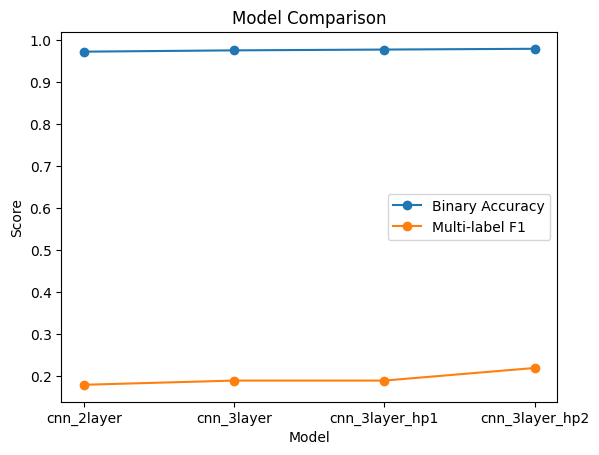

In [37]:
models = ['cnn_2layer', 'cnn_3layer', 'cnn_3layer_hp1', 'cnn_3layer_hp2']
binary_acc = [0.9719, 0.9750, 0.9769, 0.97875]
multi_f1 = [0.18, 0.19, 0.19, 0.22]

plt.figure()

plt.plot(models, binary_acc, marker='o', label='Binary Accuracy')
plt.plot(models, multi_f1, marker='o', label='Multi-label F1')

plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Model Comparison')
plt.legend()

plt.show()

In [38]:
from pathlib import Path
import pickle

def load_training_results(experiment_name):
    save_path = Path("./results") / "cnn_experiment"
    results_file = save_path / f"results_{experiment_name}.pkl"
    with open(results_file, 'rb') as f:
        return pickle.load(f)

def load_model(model_class, experiment_name, dataset, device):
    save_path = Path("./results") / "cnn_experiment"
    model_file = save_path / f"{experiment_name}.pth"
    
    model = model_class(num_classes=dataset.num_classes).to(device)
    model.load_state_dict(torch.load(model_file, map_location=device))
    model.eval()
    
    return model

In [60]:
from sklearn.metrics import classification_report

def test_model(model_class, experiment_name, dataset, device):
    model = load_model(model_class, experiment_name, dataset, device)
    results = load_training_results(experiment_name)

    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, _, binary_labels in test_loader:
            images = images.to(device)
            binary_labels = binary_labels.to(device)

            _, binary_out = model(images)
            preds = torch.argmax(binary_out, dim=1)

            correct += (preds == binary_labels).sum().item()
            total += binary_labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(binary_labels.cpu().numpy())

    test_acc = correct / total

    print("\n" + "="*50)
    print(f" {experiment_name}")
    print(f"Best Val Acc: {results['best_val_acc']:.4f}")
    print(f"Test Acc: {test_acc:.4f}")
    print("="*50)

    print(classification_report(all_labels, all_preds, target_names=['No Threat', 'Threat']))

    return {
        "name": experiment_name,
        "val_acc": results['best_val_acc'],
        "test_acc": test_acc
    }

# RUN ALL
test1 = test_model(MyCNN, "cnn_2layer", dataset, device)
test2 = test_model(My3CNN, "cnn_3layer", dataset, device)
test3 = test_model(My3CNN, "cnn_3layer_hp1", dataset, device)
test4 = test_model(My3CNN, "cnn_3layer_hp2", dataset, device)
# FINAL COMPARISON
print("\n FINAL COMPARISON")
print(f"2-layer CNN: Val={test1['val_acc']:.4f}, Test={test1['test_acc']:.4f}")
print(f"3-layer CNN: Val={test2['val_acc']:.4f}, Test={test2['test_acc']:.4f}")
print(f"3-layer tuned: Val={test3['val_acc']:.4f}, Test={test3['test_acc']:.4f}")
print(f"3-layer tuned_2: Val={test4['val_acc']:.4f}, Test={test4['test_acc']:.4f}")

/var/folders/cv/syx_rqv579bdy798blmp1n340000gn/T/ipykernel_74883/1900139673.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_file,


 cnn_2layer
Best Val Acc: 0.9769
Test Acc: 0.9719
              precision    recall  f1-score   support

   No Threat       0.98      0.98      0.98      1096
      Threat       0.96      0.95      0.96       504

    accuracy                           0.97      1600
   macro avg       0.97      0.97      0.97      1600
weighted avg       0.97      0.97      0.97      1600



/var/folders/cv/syx_rqv579bdy798blmp1n340000gn/T/ipykernel_74883/1900139673.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_file,


 cnn_3layer
Best Val Acc: 0.9781
Test Acc: 0.9750
              precision    recall  f1-score   support

   No Threat       0.98      0.99      0.98      1096
      Threat       0.97      0.95      0.96       504

    accuracy                           0.97      1600
   macro avg       0.97      0.97      0.97      1600
weighted avg       0.97      0.97      0.97      1600



/var/folders/cv/syx_rqv579bdy798blmp1n340000gn/T/ipykernel_74883/1900139673.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_file,


 cnn_3layer_hp1
Best Val Acc: 0.9781
Test Acc: 0.9762
              precision    recall  f1-score   support

   No Threat       0.97      1.00      0.98      1096
      Threat       0.99      0.93      0.96       504

    accuracy                           0.98      1600
   macro avg       0.98      0.96      0.97      1600
weighted avg       0.98      0.98      0.98      1600



/var/folders/cv/syx_rqv579bdy798blmp1n340000gn/T/ipykernel_74883/1900139673.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_file,


 cnn_3layer_hp2
Best Val Acc: 0.9819
Test Acc: 0.9788
              precision    recall  f1-score   support

   No Threat       0.97      1.00      0.98      1096
      Threat       0.99      0.94      0.97       504

    accuracy                           0.98      1600
   macro avg       0.98      0.97      0.98      1600
weighted avg       0.98      0.98      0.98      1600


 FINAL COMPARISON
2-layer CNN: Val=0.9769, Test=0.9719
3-layer CNN: Val=0.9781, Test=0.9750
3-layer tuned: Val=0.9781, Test=0.9762
3-layer tuned_2: Val=0.9819, Test=0.9788


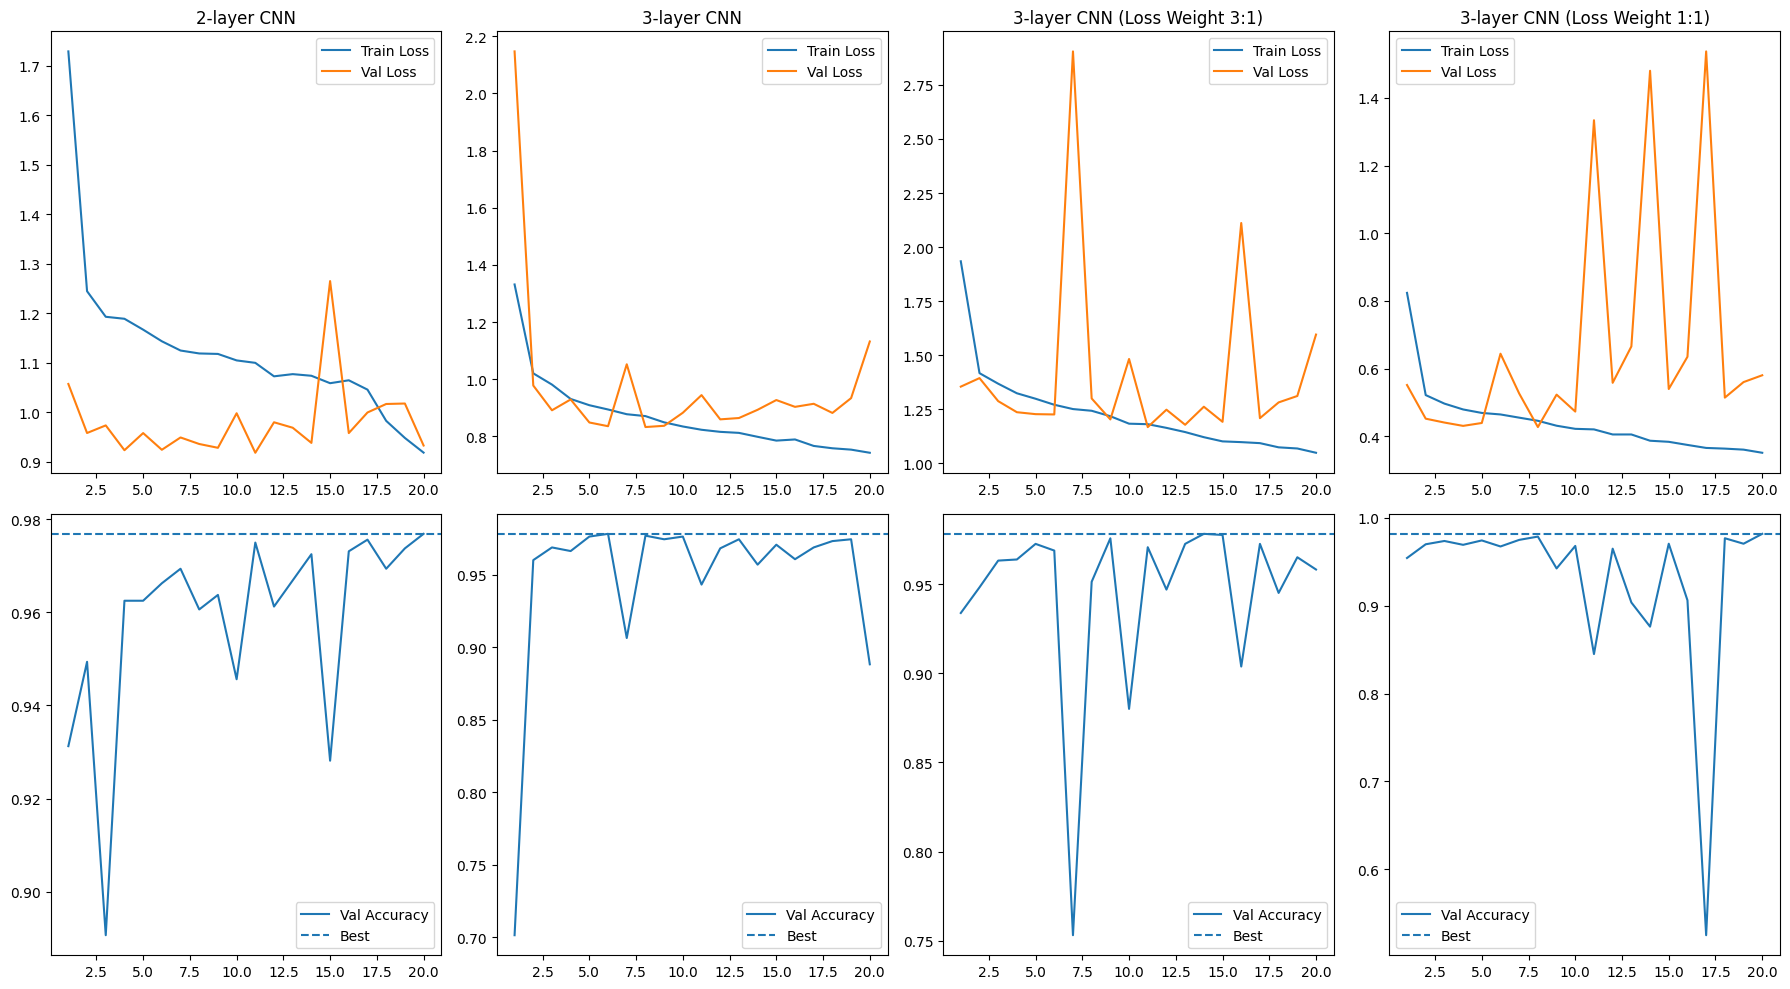

In [44]:
import matplotlib.pyplot as plt

res_2 = load_training_results("cnn_2layer")
res_3 = load_training_results("cnn_3layer")
res_hp = load_training_results("cnn_3layer_hp1")
res_hp_2 = load_training_results("cnn_3layer_hp2")

results_list = [res_2, res_3, res_hp, res_hp_2]
names = ['2-layer CNN', '3-layer CNN', '3-layer CNN (Loss Weight 3:1)', '3-layer CNN (Loss Weight 1:1)']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for i, (res, name) in enumerate(zip(results_list, names)):
    epochs = range(1, len(res['train_losses']) + 1)

    # LOSS
    axes[0, i].plot(epochs, res['train_losses'], label='Train Loss')
    axes[0, i].plot(epochs, res['val_losses'], label='Val Loss')
    axes[0, i].set_title(name)
    axes[0, i].legend()

    # ACC
    axes[1, i].plot(epochs, res['val_accs'], label='Val Accuracy')
    axes[1, i].axhline(res['best_val_acc'], linestyle='--', label='Best')
    axes[1, i].legend()

plt.tight_layout()
plt.show()

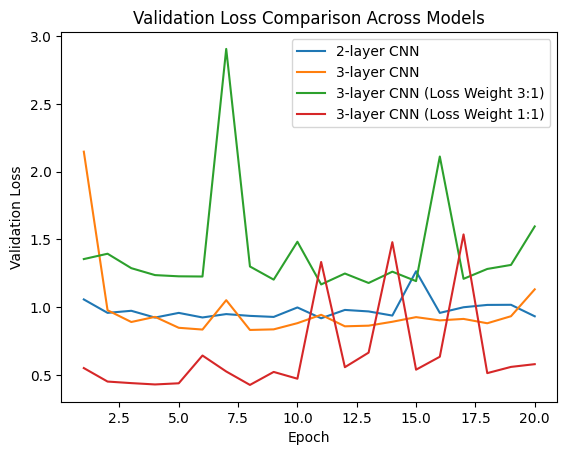

In [45]:
plt.figure()
res_2 = load_training_results("cnn_2layer")
res_3 = load_training_results("cnn_3layer")
res_hp = load_training_results("cnn_3layer_hp1")
res_hp_2 = load_training_results("cnn_3layer_hp2")

results_list = [res_2, res_3, res_hp, res_hp_2]
names = ['2-layer CNN', '3-layer CNN', '3-layer CNN (Loss Weight 3:1)', '3-layer CNN (Loss Weight 1:1)']
for res, name in zip(results_list, names):
    epochs = range(1, len(res['val_losses']) + 1)
    plt.plot(epochs, res['val_losses'], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison Across Models")
plt.legend()
plt.show()

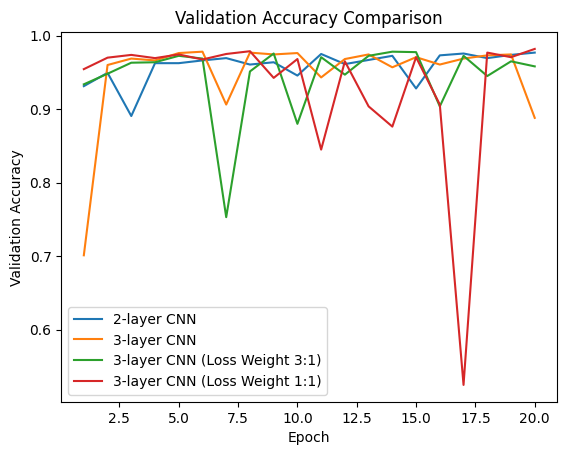

In [47]:
plt.figure()

for res, name in zip(results_list, names):
    epochs = range(1, len(res['val_accs']) + 1)
    plt.plot(epochs, res['val_accs'], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()

In [55]:
print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
res_2 = load_training_results("cnn_2layer")
res_3 = load_training_results("cnn_3layer")
res_hp = load_training_results("cnn_3layer_hp1")
res_hp_2 = load_training_results("cnn_3layer_hp2")
names = ['2-layer CNN', '3-layer CNN', '3-layer CNN (Loss Weight 3:1)', '3-layer CNN (Loss Weight 1:1)']

results_list = [res_2, res_3, res_hp, res_hp_2]
test_list= [test1, test2, test3, test4]
for res, test, name in zip(results_list, test_list, names):
    print(f"\n{name}:")
    print(f"Val Accs: {[f'{x:.4f}' for x in res['val_accs']]}")
    print(f"Best Val Accuracy: {res['best_val_acc']:.4f}")
    print(f"Test Accuracy: {test['test_acc']:.4f}")
    print(f"Final Train Loss: {res['train_losses'][-1]:.4f}")
    print(f"Final Val Loss: {res['val_losses'][-1]:.4f}")

# BEST MODEL
test_list= [test1, test2, test3, test4]
best_idx = max(range(4), key=lambda i: test_list[i]['test_acc'])

print("\nBEST MODEL:")
print(names[best_idx])
print(f"Validation Accuracy: {test_list[best_idx]['val_acc']:.4f}")
print(f"Test Accuracy: {test_list[best_idx]['test_acc']:.4f}")
print("="*60)


TRAINING SUMMARY

2-layer CNN:
Val Accs: ['0.9313', '0.9494', '0.8906', '0.9625', '0.9625', '0.9663', '0.9694', '0.9606', '0.9637', '0.9456', '0.9750', '0.9613', '0.9669', '0.9725', '0.9281', '0.9731', '0.9756', '0.9694', '0.9738', '0.9769']
Best Val Accuracy: 0.9769
Test Accuracy: 0.9719
Final Train Loss: 0.9189
Final Val Loss: 0.9333

3-layer CNN:
Val Accs: ['0.7013', '0.9600', '0.9688', '0.9663', '0.9762', '0.9781', '0.9062', '0.9769', '0.9744', '0.9762', '0.9431', '0.9681', '0.9744', '0.9569', '0.9706', '0.9606', '0.9688', '0.9731', '0.9744', '0.8881']
Best Val Accuracy: 0.9781
Test Accuracy: 0.9750
Final Train Loss: 0.7425
Final Val Loss: 1.1320

3-layer CNN (Loss Weight 3:1):
Val Accs: ['0.9337', '0.9481', '0.9631', '0.9637', '0.9725', '0.9688', '0.7531', '0.9513', '0.9756', '0.8800', '0.9706', '0.9469', '0.9725', '0.9781', '0.9775', '0.9038', '0.9725', '0.9450', '0.9650', '0.9581']
Best Val Accuracy: 0.9781
Test Accuracy: 0.9762
Final Train Loss: 1.0495
Final Val Loss: 1.5959

